In [1]:
%load_ext rpy2.ipython

In [2]:
%%R

library(DESeq2)
library(dplyr)
library(tidyverse)
library(ggplot2)
library(RColorBrewer)
library(pheatmap)
library(tximport)
library(ggrepel)
library(GenomicFeatures)
library(AnnotationHub)
library(ensembldb)
library(stringr)
library(biomaRt)
library(pheatmap)
library(EnhancedVolcano)
library(org.Mm.eg.db)
library(gprofiler2)
library(ChIPpeakAnno)
library(TxDb.Mmusculus.UCSC.mm10.ensGene)
library(ChIPseeker)
library(clusterProfiler)
library(stringr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()       masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()       masks S4Vectors::rename()
✖ lubridate::second()  

Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Attaching package: ‘S4Vectors’

The following object is masked from ‘package:utils’:

    findMatches

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package: IRanges
Loading required package: GenomicRanges
Loading required package: GenomeInfoDb
Loading requ

## Get pseudobulk data from open-source scRNA-seq data of Old and Control samples

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import scanpy as sc
from adpbulk import ADPBulk

In [4]:
from importlib.metadata import version
version('adpbulk')

'0.1.4'

In [5]:
df = sc.read_h5ad('/tank/projects/kashuk_sirt6_hic/old_rnaseq/BrainAgingSpatialAtlas_snRNAseq.h5ad')

In [6]:
adpb = ADPBulk(df, ["cell_type", "age", "donor_id"], use_raw=True)

In [7]:
filtered_df = df.var[df.var['feature_name'].str.contains('Ighv', regex=True)]

In [8]:
pseudobulk_matrix = adpb.fit_transform()

Aggregating Samples: 100%|██████████| 104/104 [00:12<00:00,  8.39it/s]


In [9]:
sample_meta = adpb.get_meta()

In [10]:
sample_meta.cell_type.unique()

array(['T cell', 'astrocyte', 'cell', 'endothelial cell',
       'inhibitory interneuron', 'macrophage', 'medium spiny neuron',
       'microglial cell', 'neuron', 'oligodendrocyte',
       'oligodendrocyte precursor cell', 'pericyte',
       'vascular leptomeningeal cell'], dtype=object)

In [11]:
neuronal_types = ["inhibitory interneuron", "medium spiny neuron", "neuron"]

neuron_rows = pseudobulk_matrix[pseudobulk_matrix.index.str.contains("|".join(neuronal_types))]
nonneuron_rows = pseudobulk_matrix[~pseudobulk_matrix.index.str.contains("|".join(neuronal_types))]

In [12]:
df_4wk = neuron_rows[neuron_rows.index.str.startswith("age.4wk")]
df_90wk = neuron_rows[neuron_rows.index.str.startswith("age.90wk")]

glia_df_4wk = nonneuron_rows[nonneuron_rows.index.str.startswith("age.4wk")]
glia_df_90wk = nonneuron_rows[nonneuron_rows.index.str.startswith("age.90wk")]

In [13]:
df_4wk.index = df_4wk.index.str.replace(r'cell_type\..*?-donor_id', 'donor_id', regex=True)
df_90wk.index = df_90wk.index.str.replace(r'cell_type\..*?-donor_id', 'donor_id', regex=True)

In [14]:
df_4wk_grouped = df_4wk.groupby(df_4wk.index).sum()
df_90wk_grouped = df_90wk.groupby(df_90wk.index).sum()

In [15]:
replacement_patterns = {
    '|'.join(['-cell_type', '-donor_id', '10X_MsBrainAgingSpatial']): '',
    r'age\.4wk': '4wk',
    r'age\.90wk': '90wk',
    r'\.cell\.': '.ependymal cells.', 
    r' ': '_'
}

for pattern, replacement in replacement_patterns.items():
    glia_df_4wk.index = glia_df_4wk.index.str.replace(pattern, replacement, regex=True)
    glia_df_90wk.index = glia_df_90wk.index.str.replace(pattern, replacement, regex=True)

In [16]:
df_4wk_grouped.index = [f"4wk.sample{i+1}" for i in range(len(df_4wk_grouped))]
df_90wk_grouped.index = [f"90wk.sample{i+1}" for i in range(len(df_90wk_grouped))]

In [17]:
df_4wk_grouped_transposed = df_4wk_grouped.T
df_90wk_grouped_transposed = df_90wk_grouped.T

glia_df_4wk_transposed = glia_df_4wk.T
glia_df_90wk_transposed = glia_df_90wk.T

In [18]:
df_merged = df_4wk_grouped_transposed.merge(df_90wk_grouped_transposed, left_index=True, right_index=True, how="inner") 
glia_df_merged = glia_df_4wk_transposed.merge(glia_df_90wk_transposed, left_index=True, right_index=True, how="inner") 

In [32]:
%%R
library(AnnotationHub)

ah <- AnnotationHub()
mm10_ens <- query(ah, c("Mus musculus", "EnsDb"))
mm10_ens <- mm10_ens[["AH109655"]]

genedb <- genes(mm10_ens, return.type = "data.frame")
genedb2 <- dplyr::select(genedb, gene_id, symbol)

txdb <- transcripts(mm10_ens, return.type = "data.frame")
txdb2 <- dplyr::select(txdb, tx_id, gene_id)

tx2gene <- right_join(txdb2, genedb2, by='gene_id')

snapshotDate(): 2024-10-28
loading from cache


## Old/Control samples

In [21]:
%%R

data <- read.csv("/tank/projects/kashuk_sirt6_hic/old_rnaseq/pseudobulk_expression_raw_counts_4wk_90wk.csv", sep=',', row.names = 1)
genotype <- factor(c(rep("Control", 2), rep("Old",2)))

meta <- data.frame(genotype, row.names = colnames(data))

In [22]:
%%R

dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ genotype)

dds <- estimateSizeFactors(dds)
sizeFactors(dds)

colSums(counts(dds))

normalized_counts <- counts(dds, normalized=TRUE)

converting counts to integer mode


In [23]:
%%R

rld <- rlog(dds, blind=TRUE)

In addition: Warning messages:
1: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
2: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


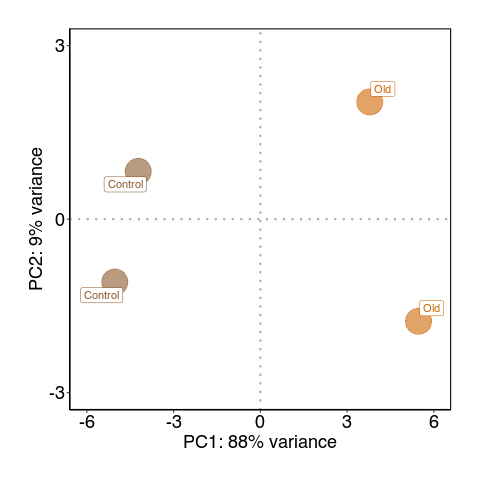

In [24]:
%%R

library(ggrepel)

intgroup <- "genotype"
ntop <- 300

rv <- rowVars(assay(rld))

select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]

pca <- prcomp(t(assay(rld)[select, ]))

percentVar <- pca$sdev^2/sum(pca$sdev^2)

intgroup.df <- as.data.frame(colData(rld)[, intgroup, drop = FALSE])
group <- if (length(intgroup) > 1) {
  factor(apply(intgroup.df, 1, paste, collapse = " : "))
} else {
  colData(rld)[[intgroup]]
}

d1 <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], intgroup.df, name = colnames(rld))

d1$genotype <- c(rep('Control', 2), rep('Old', 2))

ggplot(d1, aes(x=PC1, y=PC2, colour = genotype)) + 
  geom_point(size=12, alpha = 0.6) +
  scale_y_continuous(limits = c(-3, 3), breaks = c(-3,0,3))+
  xlim(-6, 6) +
  xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
  ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  geom_label_repel(aes(label = genotype),
                   box.padding   = 0.3, 
                   point.padding = 0.1,
                   segment.color = 'grey50',
                   force         = 0.1,
                   segment.size  = 0.2,
                   max.overlaps = 100,
                   angle = 40
  ) +
  theme(axis.text.y   = element_text(size=18,colour = "black"),
        axis.text.x   = element_text(size=18,colour = "black"),
        axis.title.y  = element_text(size=18,colour = "black"),
        axis.title.x  = element_text(size=18,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "none",
        aspect.ratio = 4/4,
        plot.margin = unit(c(1,1,1,1), "cm")
  ) +
  scale_colour_manual(values = c('tan4', 'darkorange3'))

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


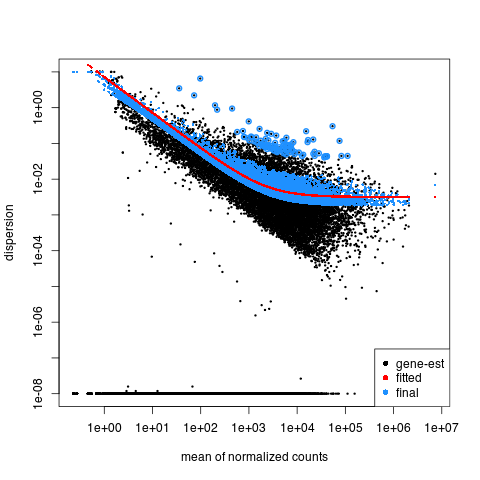

In [27]:
%%R

dds_analysis <- DESeq(dds)
plotDispEsts(dds_analysis)
contrast <- c("genotype", "Old", "Control")
res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)
res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

In [34]:
%%R

summary(res)
padj.cutoff <- 0.05
lfc.cutoff <- 0
res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>% dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)
res.df <- as.data.frame(res)
res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')
sig_old <- left_join(sig, genedb2, by=c('gene'='gene_id'))


out of 20742 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 1779, 8.6%
LFC < 0 (down)     : 1347, 6.5%
outliers [1]       : 0, 0%
low counts [2]     : 4823, 23%
(mean count < 29)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



## shSIRT6/shCtrl samples

In [35]:
%%R

samples <- list.files(path = "/tank/projects/kashuk_rnaseq/rnaseq/", full.names = T) 
files <- file.path(samples, "quant.sf")
names(files) <- str_replace(samples, "/tank/projects/kashuk_rnaseq/rnaseq", "")

txi <- tximport(files, 
                type="salmon", 
                tx2gene=tx2gene[,c("tx_id", "gene_id")],
                countsFromAbundance="lengthScaledTPM")
attributes(txi)
data <- data.frame(round(txi$counts))

reading in files with read_tsv
1 2 3 4 5 
transcripts missing from tx2gene: 5640
summarizing abundance
summarizing counts
summarizing length


In [36]:
%%R

genotype <- factor(c(rep("shCtrl", 3), rep("shSIRT6",2)))
meta <- data.frame(genotype, row.names = colnames(data))

In [37]:
%%R

dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ genotype)
dds <- estimateSizeFactors(dds)
sizeFactors(dds)
normalized_counts <- counts(dds, normalized=TRUE)

converting counts to integer mode


In [38]:
%%R

rld <- rlog(dds, blind=TRUE)

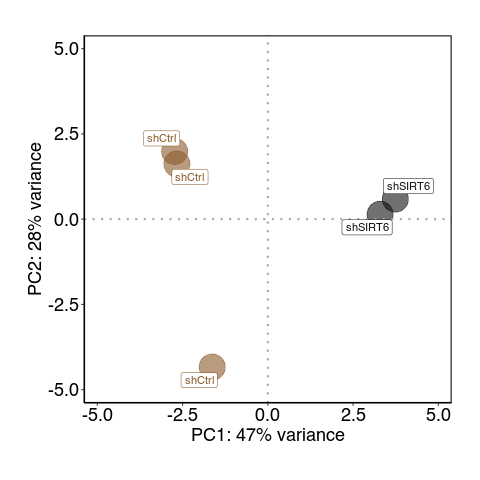

In [39]:
%%R

intgroup <- "genotype"
ntop <- 500

rv <- rowVars(assay(rld))

select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]

pca <- prcomp(t(assay(rld)[select, ]))

percentVar <- pca$sdev^2/sum(pca$sdev^2)

intgroup.df <- as.data.frame(colData(rld)[, intgroup, drop = FALSE])
group <- if (length(intgroup) > 1) {
  factor(apply(intgroup.df, 1, paste, collapse = " : "))
} else {
  colData(rld)[[intgroup]]
}

d1 <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], intgroup.df, name = colnames(rld))

d1$genotype <- c(rep("shCtrl", 3), rep("shSIRT6",2))

ggplot(d1, aes(x=PC1, y=PC2, colour = genotype)) + 
  geom_point(size=12, alpha = 0.6) +
  ylim(-4.9, 4.9) + xlim(-4.9, 4.9) +
  xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
  ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  geom_label_repel(aes(label = genotype),
                   box.padding   = 0.3, 
                   point.padding = 0.1,
                   segment.color = 'grey50',
                   force         = 0.1,
                   segment.size  = 0.2,
                   max.overlaps = 100,
                   angle = 40
  ) +
  theme(axis.text.y   = element_text(size=18,colour = "black"),
        axis.text.x   = element_text(size=18,colour = "black"),
        axis.title.y  = element_text(size=18,colour = "black"),
        axis.title.x  = element_text(size=18,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "none",
        aspect.ratio = 4/4,
        plot.margin = unit(c(1,1,1,1), "cm")
  ) +
  scale_colour_manual(values = c('tan4', 'gray7'))

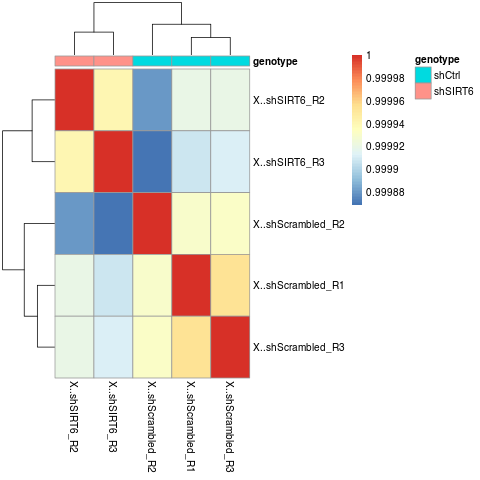

In [40]:
%%R

rld_mat <- assay(rld)
rld_cor <- cor(rld_mat)
pheatmap(rld_cor, annotation = meta)

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


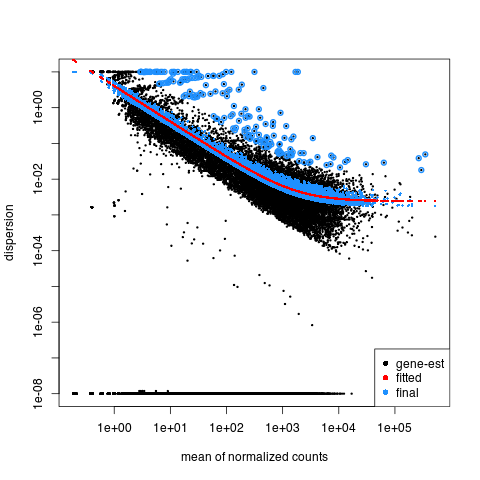

In [42]:
%%R
dds_analysis <- DESeq(dds)
plotDispEsts(dds_analysis)
contrast <- c("genotype", "shSIRT6", "shCtrl")
res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)
res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

In [43]:
%%R

summary(res)
padj.cutoff <- 0.05
lfc.cutoff <- 0
res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>% dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)
res.df <- as.data.frame(res)
res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')
sig_s6 <- left_join(sig, genedb2, by=c('gene'='gene_id'))
dim(sig_s6)


out of 25433 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 331, 1.3%
LFC < 0 (down)     : 562, 2.2%
outliers [1]       : 1, 0.0039%
low counts [2]     : 15786, 62%
(mean count < 354)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

[1] 893   8


## Step1, Step2, Control samples

In [44]:
%%R

samples <- list.files(path = "/tank/projects/kashuk_sirt6_hic/ad/rnaseq/salmon_quants", full.names = T) 
files <- file.path(samples, "quant.sf")
names(files) <- str_replace(samples, "/tank/projects/kashuk_sirt6_hic/ad/rnaseq/salmon_quants", "")
txi <- tximport(files, 
                type="salmon", 
                tx2gene=tx2gene[,c("tx_id", "gene_id")],
                countsFromAbundance="lengthScaledTPM")

attributes(txi)

data <- data.frame(round(txi$counts))

reading in files with read_tsv
1 2 3 4 5 6 
transcripts missing from tx2gene: 5640
summarizing abundance
summarizing counts
summarizing length


In [45]:
%%R

genotype <- factor(c(rep("Control", 2), rep("Step1",2), rep("Step2",2)))
meta <- data.frame(genotype, row.names = colnames(data))

In [47]:
%%R

dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ genotype)
dds <- estimateSizeFactors(dds)
sizeFactors(dds)
colSums(counts(dds))
normalized_counts <- counts(dds, normalized=TRUE)

converting counts to integer mode


In [48]:
%%R
rld <- rlog(dds, blind=TRUE)

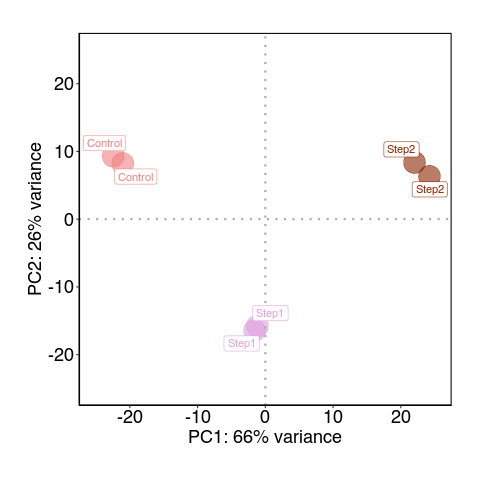

In [49]:
%%R

intgroup <- "genotype"
ntop <- 300

rv <- rowVars(assay(rld))
select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]
pca <- prcomp(t(assay(rld)[select, ]))

percentVar <- pca$sdev^2/sum(pca$sdev^2)

intgroup.df <- as.data.frame(colData(rld)[, intgroup, drop = FALSE])
group <- if (length(intgroup) > 1) {
  factor(apply(intgroup.df, 1, paste, collapse = " : "))
} else {
  colData(rld)[[intgroup]]
}

d1 <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], intgroup.df, name = colnames(rld))
d1$genotype <- c(rep('Control', 2), rep('Step1', 2), rep('Step2', 2))

ggplot(d1, aes(x=PC1, y=PC2, colour = genotype)) + 
  geom_point(size=10, alpha = 0.6) +
  ylim(-25, 25) + xlim(-25, 25) +
  xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
  ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  geom_label_repel(aes(label = genotype),
                   box.padding   = 0.3, 
                   point.padding = 0.1,
                   segment.color = 'grey50',
                   force         = 0.1,
                   segment.size  = 0.2,
                   max.overlaps = 100,
                   angle = 40
  ) +
  theme(axis.text.y   = element_text(size=18,colour = "black"),
        axis.text.x   = element_text(size=18,colour = "black"),
        axis.title.y  = element_text(size=18,colour = "black"),
        axis.title.x  = element_text(size=18,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "none",
        aspect.ratio = 4/4,
        plot.margin = unit(c(1,1,1,1), "cm")
  ) +
  scale_colour_manual(values = c('lightcoral', 'plum', 'orangered4'))

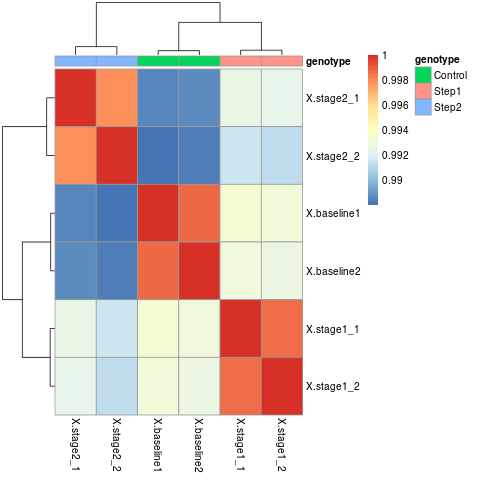

In [53]:
%%R
rld_mat <- assay(rld)
rld_cor <- cor(rld_mat)
pheatmap(rld_cor, annotation = meta)

### Step1 vs Control

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


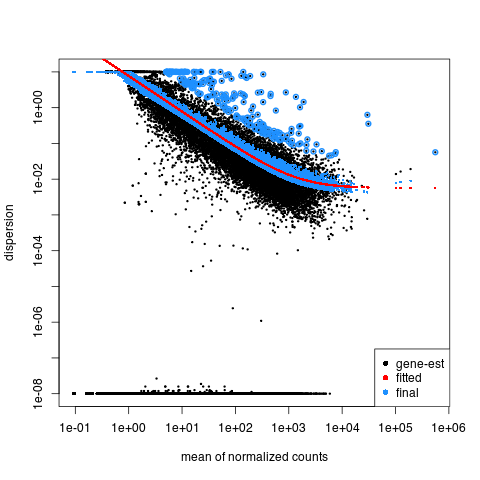

In [54]:
%%R

dds_analysis <- DESeq(dds)
plotDispEsts(dds_analysis)
contrast <- c("genotype", "Step1", "Control")
res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)
res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

In [55]:
%%R

summary(res)

padj.cutoff <- 0.05
lfc.cutoff <- 0
res_tb <- res %>% data.frame() %>% rownames_to_column(var = "gene") %>% as_tibble()
sig <- res_tb %>%dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)
res.df <- as.data.frame(res)
res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')
sig_step1 <- left_join(sig, genedb2, by=c('gene'='gene_id'))


out of 28247 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 3208, 11%
LFC < 0 (down)     : 2878, 10%
outliers [1]       : 0, 0%
low counts [2]     : 8573, 30%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



### Step2 vs Control

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


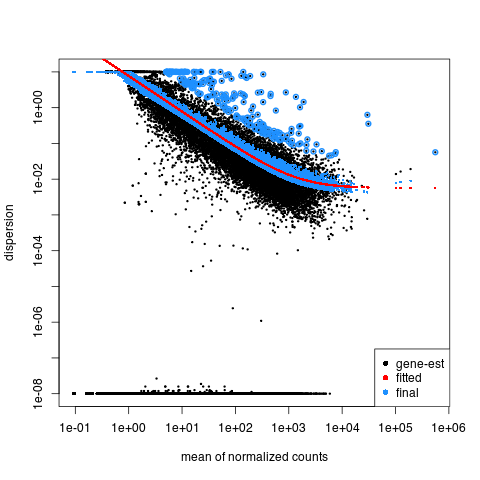

In [56]:
%%R

dds_analysis <- DESeq(dds)
plotDispEsts(dds_analysis)
contrast <- c("genotype", "Step2", "Control")
res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)
res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

In [57]:
%%R

summary(res)

padj.cutoff <- 0.05
lfc.cutoff <- 0
res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>% dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)
res.df <- as.data.frame(res)
res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')
sig_step2 <- left_join(sig, genedb2, by=c('gene'='gene_id'))


out of 28247 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 4886, 17%
LFC < 0 (down)     : 4231, 15%
outliers [1]       : 0, 0%
low counts [2]     : 9109, 32%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results




Attaching package: 'reshape2'

The following object is masked from 'package:tidyr':

    smiths


Attaching package: 'ggVennDiagram'

The following object is masked from 'package:ChIPseeker':

    overlap

The following object is masked from 'package:tidyr':

    unite



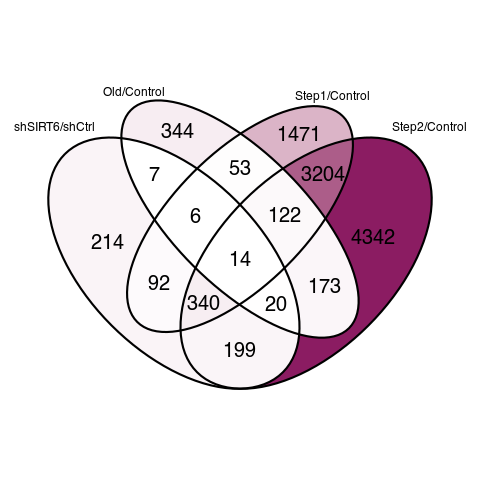

In [58]:
%%R

library(reshape2)
library(ggVennDiagram)

ko <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_shSIRT6_shCtrl.csv', row.names = 1)
s1 <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step1_Control.csv', row.names = 1)
s2 <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Step2_Control.csv', row.names = 1)
old <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/sig_genes_pvalue_0.05_lfc_0.58_Old_Control.csv', row.names = 1)

gene_list <- list('shSIRT6/shCtrl' = ko$symbol, 'Old/Control' = old$symbol, 'Step1/Control' = s1$symbol, 'Step2/Control' = s2$symbol)

ggVennDiagram(gene_list, label = "count", label_alpha = 0, label_size =7) + 
  scale_fill_gradient(low = "white", high = "maroon4") + 
  theme(
    legend.position = "none", 
    text = element_text(size = 16), 
    strip.text = element_text(size = 25),  
    panel.grid = element_blank(),  # Remove grid
    plot.margin = margin(10, 10, 10, 10)
  ) +
  scale_x_continuous(expand = expansion(mult = 0.1))

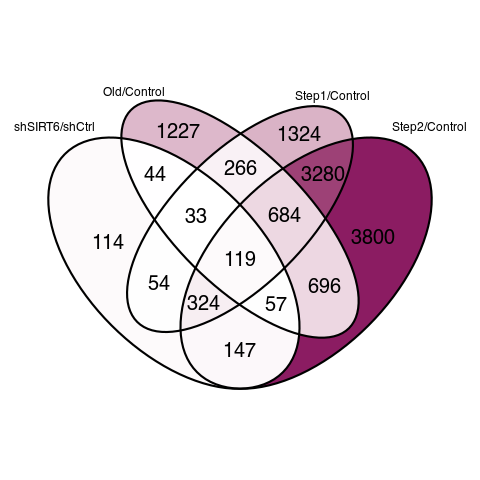

In [59]:
%%R

gene_list <- list('shSIRT6/shCtrl' = sig_s6$symbol, 
                  'Old/Control' = sig_old$symbol,
                  'Step1/Control' = sig_step1$symbol,
                  'Step2/Control' = sig_step2$symbol)

ggVennDiagram(gene_list, label = "count", label_alpha = 0, label_size =7) + 
  scale_fill_gradient(low = "white", high = "maroon4") + 
  theme(
    legend.position = "none", 
    text = element_text(size = 16), 
    strip.text = element_text(size = 25),  
    panel.grid = element_blank(),  # Remove grid
    plot.margin = margin(10, 10, 10, 10)
  ) +
  scale_x_continuous(expand = expansion(mult = 0.1))

## Heatmap of jaccard index values between 

In [60]:
%%R
library(GeneOverlap)

In [61]:
%%R

dm.up <- list(`Old` = sig_old %>% filter(log2FoldChange > 0) %>% .$gene, 
              `Step1` = sig_step1 %>% filter(log2FoldChange > 0) %>% .$gene, 
              `Step2` = sig_step2 %>% filter(log2FoldChange > 0) %>% .$gene)

dm.down <- list(`Old` = sig_old %>% filter(log2FoldChange < 0) %>% .$gene, 
                `Step1` = sig_step1 %>% filter(log2FoldChange < 0) %>% .$gene, 
                `Step2` = sig_step2 %>% filter(log2FoldChange < 0) %>% .$gene)

s6ko.up <- list(`S6-KO Down` = sig_s6 %>% filter(log2FoldChange < 0) %>% .$gene, 
                `S6-KO Up` = sig_s6 %>% filter(log2FoldChange > 0) %>% .$gene)

ko_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_shSIRT6_shCtrl.csv', row.names = 1)
old_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Old_Control.csv', row.names = 1)
s1_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step1_Control.csv', row.names = 1)
s2_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step2_Control.csv', row.names = 1)

## Only expressing genes as background
s1_all_filt <- s1_all %>% 
  dplyr::filter(baseMean > 0)
s2_all_filt <- s2_all %>% 
  dplyr::filter(baseMean > 0)
ko_all_filt <- ko_all %>% 
  dplyr::filter(baseMean > 0)
old_all_filt <- ko_all %>% 
  dplyr::filter(baseMean > 0)

all_genes <- Reduce(intersect, list(s1_all_filt$gene_id, s2_all_filt$gene_id, ko_all_filt$gene_id, old_all_filt$gene_id))

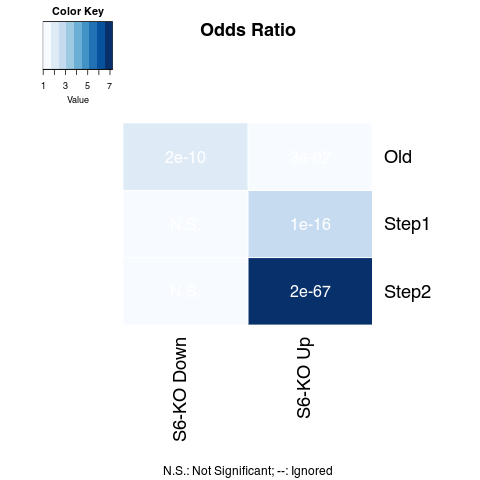

In [62]:
%%R

gom.obj.up <- newGOM(dm.up, s6ko.up, length(all_genes))
gom.obj.up
drawHeatmap(gom.obj.up, grid.col="Blues", note.col="white")

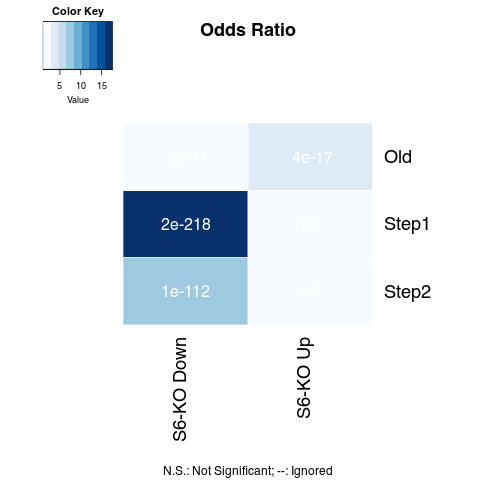

In [63]:
%%R

gom.obj.down <- newGOM(dm.down, s6ko.up, length(all_genes))
gom.obj.down
drawHeatmap(gom.obj.down, grid.col="Blues", note.col="white")

In [64]:
%%R

library("gplots")

drawHeatmap.my <- function(object, what=c("odds.ratio", "Jaccard"), log.scale=F, adj.p=F, 
             cutoff=.05, ncolused=9, grid.col=c("Greens", "Blues", "Greys", 
                                                "Oranges", "Purples", "Reds"),
             note.col="red") {
        
        stopifnot(cutoff > 0 && cutoff <= 1)
        what <- match.arg(what)
        grid.col <- match.arg(grid.col)
        
        pv.mat <- getMatrix(object, "pval")
        plot.mat <- switch(what, 
                           odds.ratio=getMatrix(object, "odds.ratio"),
                           Jaccard=getMatrix(object, "Jaccard")
        )
        if(what == "odds.ratio" && log.scale) {
            plot.mat <- log2(plot.mat)
        }
        
        pv.mask <- NULL
        if(object@self.compare) {
            pv.mask <- sapply(1:ncol(pv.mat), function(j) {
                c(rep(T, j), rep(F, nrow(pv.mat) - j))
            })
        }
        if(adj.p) {
            if(object@self.compare) {
                pv.mat[pv.mask] <- p.adjust(pv.mat[pv.mask], method='BH')
            } else {
                pv.mat <- matrix(p.adjust(pv.mat, method='BH'), 
                                 nrow=nrow(pv.mat))
            }
        }
        
        insig.val <- 1
        if(what == "odds.ratio" && log.scale || what == "Jaccard") {
            insig.val <- 0
        }
        
        note.mat <- format(pv.mat, digits=1)
        note.mat[pv.mat < .01] <- format(pv.mat, digits=1, 
                                         scientific=T)[pv.mat < .01]
        note.mat[plot.mat == insig.val] <- "N.S."
        if(object@self.compare) { note.mat[ !pv.mask ] <- "--" }
        
        row_sep <- 1:(nrow(plot.mat) - 1)
        col_sep <- 1:(ncol(plot.mat) - 1)
        longedge <- max(nrow(plot.mat), ncol(plot.mat))
        row_cexrc <- 0.4 + 1/log10(longedge + 2)
        col_cexrc <- row_cexrc
        key_size <- 0.2 + 1 / log10(longedge + 4)
        margins_use <- c(max(nchar(colnames(plot.mat))) * 0.8 + 5, 
                         max(nchar(rownames(plot.mat))) * 0.8 + 5)
        main.txt <- switch(what, 
                           odds.ratio=ifelse(log.scale, "log2(Odds Ratio)", 
                                             "Odds Ratio"), 
                           Jaccard="Jaccard Index")
        footnote <- NULL
        sidenote <- sprintf("Log Scale=%s", log.scale)

        heatmap.2(plot.mat, offsetCol = -30,
                  cellnote=note.mat, 
                  main=main.txt, 
                  xlab=footnote, # ylab=sidenote,
                  col=brewer.pal(ncolused, grid.col), 
                  notecol=note.col, 
                  margins=margins_use, 
                  colsep=col_sep, 
                  rowsep=row_sep, 
                  key=T, 
                  keysize=key_size,
                  cexRow=row_cexrc, 
                  cexCol=col_cexrc, 
                  scale='none', 
                  Colv=NA, 
                  Rowv=NA, 
                  trace='none', 
                  dendrogram='none', 
                  density.info='none', 
                  sepcolor='white', 
                  sepwidth=c(0.002,0.002),
                  notecex=1.6
                 )
    
    return (plot.mat)    
    }


Attaching package: 'gplots'

The following object is masked from 'package:IRanges':

    space

The following object is masked from 'package:S4Vectors':

    space

The following object is masked from 'package:stats':

    lowess



In [65]:
%%R

pv.mat.up <- getMatrix(gom.obj.up, "pval") 
plot.mat.up <- getMatrix(gom.obj.up, "Jaccard") 

pv.mat.down <- getMatrix(gom.obj.down, "pval") 
plot.mat.down <- getMatrix(gom.obj.down, "Jaccard") 

pv.mat.up <- matrix(p.adjust(pv.mat.up, method='BH'), nrow=nrow(pv.mat.up))
pv.mat.down <- matrix(p.adjust(pv.mat.down, method='BH'), nrow=nrow(pv.mat.down))

print(pv.mat.up)
print(pv.mat.down)

insig.val <- 0
cutoff <- 0.05

note.mat.up <- format(pv.mat.up, digits=2)
note.mat.up[pv.mat.up < 0.05] <- format(pv.mat.up, digits=2, scientific=T)[pv.mat.up < 0.05]
note.mat.up[pv.mat.up > 0.05] <- "N.S."

note.mat.down <- format(pv.mat.down, digits=1)
note.mat.down[pv.mat.down < 0.05] <- format(pv.mat.down, digits=1, scientific=T)[pv.mat.down < 0.05]
note.mat.down[pv.mat.down > 0.05] <- "N.S."

col_fun = circlize::colorRamp2(seq(0, 0.155, 0.018), brewer.pal(9, "Blues"))

             [,1]         [,2]
[1,] 4.816277e-10 5.105686e-02
[2,] 1.000000e+00 2.951446e-16
[3,] 1.000000e+00 9.608721e-67
              [,1]         [,2]
[1,]  8.042659e-11 8.025333e-17
[2,] 1.049732e-217 9.751343e-01
[3,] 4.301918e-112 1.000000e+00


Loading required package: grid
ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))
! pheatmap() has been masked by ComplexHeatmap::pheatmap(). Most of the arguments
   in the original pheatmap() are identically supported in the new function. You 
   can still use the original function by explicitly calling pheatmap::pheatmap().


Attaching package: 'Comp

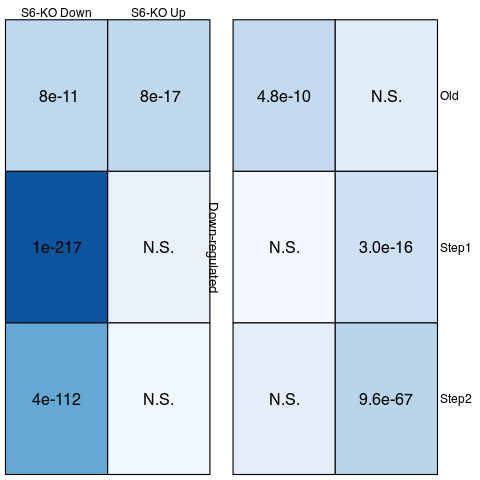

In [66]:
%%R

library(ComplexHeatmap)

h.up <- Heatmap(plot.mat.up, name = 'Jaccard\nIndex', show_heatmap_legend = F, show_column_names = F,
                cluster_rows = F, 
                cluster_columns = F, 
                col = col_fun,
                cell_fun = function(j, i, x, y, width, height, fill) {
                    grid.text(note.mat.up[i, j], x, y, gp = gpar(fontsize = 16, col = "black"))
                },
                column_names_rot = 0, column_names_side = "top", column_names_centered = T,
                row_title = "Up-regulated", row_title_side = "right",
                rect_gp = gpar(col = "black", lwd = 1.5))

h.down <- Heatmap(plot.mat.down, name = ' Jaccard\nIndex', show_heatmap_legend = F,
                  cluster_rows = F, 
                  cluster_columns = F, 
                  col = col_fun, 
                  cell_fun = function(j, i, x, y, width, height, fill) {
                    grid.text(note.mat.down[i, j], x, y, gp = gpar(fontsize = 16, col = "black"))
                  },
                  column_names_rot = 0, column_names_side = "top", column_names_centered = T,
                  row_title = "Down-regulated", row_title_side = "right",
                  rect_gp = gpar(col = "black", lwd = 1.5))

draw(h.down + h.up, merge_legend = TRUE)

## REACTOME analysis

In [83]:
%%R

ko_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_shSIRT6_shCtrl.csv', row.names = 1)
s1_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step1_Control.csv', row.names = 1)
s2_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step2_Control.csv', row.names = 1)

## Only expressing genes as background
s1_all_filt <- s1_all %>% 
  dplyr::filter(baseMean > 0)
s2_all_filt <- s2_all %>% 
  dplyr::filter(baseMean > 0)
ko_all_filt <- ko_all %>% 
  dplyr::filter(baseMean > 0)

all_genes <- union(s1_all_filt$symbol, s2_all_filt$symbol)
all_genes <- unique(union(all_genes, ko_all_filt$symbol))

mart <- useEnsembl("ENSEMBL_MART_ENSEMBL", dataset="mmusculus_gene_ensembl", version=108)

back <- getBM(filters = "external_gene_name",
              attributes = c("entrezgene_id","ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
              values = all_genes, 
              mart = mart)

Error in `req_perform()`:
! Failed to perform HTTP request.
Caused by error in `curl::curl_fetch_memory()`:
! Timeout was reached [oct2022.archive.ensembl.org]: Operation timed out after 60000 milliseconds with 0 bytes received
Run `rlang::last_trace()` to see where the error occurred.

Error in req_perform(request) : 
Caused by error in `curl::curl_fetch_memory()`:
! Timeout was reached [oct2022.archive.ensembl.org]: Operation timed out after 60000 milliseconds with 0 bytes received


RInterpreterError: Failed to parse and evaluate line '\n## Background\n\nko_all <- read.csv(\'/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_shSIRT6_shCtrl.csv\', row.names = 1)\ns1_all <- read.csv(\'/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step1_Control.csv\', row.names = 1)\ns2_all <- read.csv(\'/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step2_Control.csv\', row.names = 1)\n\n## Only expressing genes as background\ns1_all_filt <- s1_all %>% \n  dplyr::filter(baseMean > 0)\ns2_all_filt <- s2_all %>% \n  dplyr::filter(baseMean > 0)\nko_all_filt <- ko_all %>% \n  dplyr::filter(baseMean > 0)\n\nall_genes <- union(s1_all_filt$symbol, s2_all_filt$symbol)\nall_genes <- unique(union(all_genes, ko_all_filt$symbol))\n\nmart <- useEnsembl("ENSEMBL_MART_ENSEMBL", dataset="mmusculus_gene_ensembl", version=108)\n\nback <- getBM(filters = "external_gene_name",\n              attributes = c("entrezgene_id","ensembl_gene_id", "external_gene_name", "gene_biotype", "descr

In [ ]:
%%R

ko <- sig_s6
s1 <- sig_step1
s2 <- sig_step2

ko_s1_up <- subset(ko, symbol %in% intersect(ko %>% filter(log2FoldChange > 0) %>% .$symbol, 
                                             s1 %>% filter(log2FoldChange > 0) %>% .$symbol))

ko_s1_down <- subset(ko, symbol %in% intersect(ko %>% filter(log2FoldChange < 0) %>% .$symbol, 
                                             s1 %>% filter(log2FoldChange < 0) %>% .$symbol))

ko_s2_up <- subset(ko, symbol %in% intersect(ko %>% filter(log2FoldChange > 0) %>% .$symbol, 
                                             s2 %>% filter(log2FoldChange > 0) %>% .$symbol))

ko_s2_down <- subset(ko, symbol %in% intersect(ko %>% filter(log2FoldChange < 0) %>% .$symbol, 
                                             s2 %>% filter(log2FoldChange < 0) %>% .$symbol))

In [ ]:
%%R

ko_s1_up

### Step1/Control & shSIRT6/shCtrl

In [ ]:
%%R

library(ReactomePA)
library(enrichplot)

gene_annotations_up <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(ko_s1_up$symbol), 
  mart = mart
)

gene_annotations_down <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(ko_s1_down$symbol), 
  mart = mart
)

upregulated <- merge(
  ko_s1_up, 
  gene_annotations_up, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)

downregulated <- merge(
  ko_s1_down, 
  gene_annotations_down, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)

# Pathway analysis 
pathway_analysis <- list(
  upregulated = enrichPathway(
    gene = upregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  ),
  
  downregulated = enrichPathway(
    gene = downregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  )
)

In [ ]:
%%R

edo_up_step1 <- pairwise_termsim(pathway_analysis$upregulated)
edo_down_step1 <- pairwise_termsim(pathway_analysis$downregulated)

results <- list(
  upregulated_pathways = as.data.frame(pathway_analysis$upregulated),
  downregulated_pathways = as.data.frame(pathway_analysis$downregulated),

  edo_upregulated = as.data.frame(edo_up_step1),
  edo_downregulated = as.data.frame(edo_down_step1)
)

In [ ]:
%%R

write.csv(results$edo_upregulated, 'reactome_upregulated_common_DEGs_shSIRT6_Step1.csv')
write.csv(results$edo_downregulated, 'reactome_downregulated_common_DEGs_shSIRT6_Step1.csv')

In [ ]:
%%R

group_tree_custom <- function(hc, clus, d, offset_tiplab, nWords, 
                       label_format_cladelab, label_format_tiplab,
                       offset, fontsize, group_color, 
                       extend, hilight, cex_category, 
                       ID_Cluster_mat = NULL, geneClusterPanel = NULL,
                       align, add_tippoint = TRUE, align_tiplab = TRUE, color) {
    group <- count <- NULL
    # cluster data
    dat <- data.frame(name = names(clus), cls=paste0("cluster_", as.numeric(clus)))
    grp <- apply(table(dat), 2, function(x) names(x[x == 1]))  
    p <- ggtree(hc, hang=-1, branch.length = "none", show.legend=FALSE)
    # extract the most recent common ancestor
    noids <- lapply(grp, function(x) unlist(lapply(x, function(i) ggtree::nodeid(p, i))))
    roots <- unlist(lapply(noids, function(x) ggtree::MRCA(p, x)))
    # cluster data
    p <- ggtree::groupOTU(p, grp, "group") + aes_(color =~ group)
    rangeX <- max(p$data$x, na.rm=TRUE) - min(p$data$x, na.rm=TRUE)
    if (inherits(offset_tiplab, "rel")) {
        offset_tiplab <- unclass(offset_tiplab)
        if (geneClusterPanel == "pie" || is.null(geneClusterPanel)) {
        ## 1.5 * max(radius_of_pie)
            offset_tiplab <- offset_tiplab * .5 * max(sqrt(d$count / sum(d$count) * cex_category))
        }  else if (geneClusterPanel == "heatMap") {
            ## Close to the width of the tree
            offset_tiplab <- offset_tiplab * 0.2 * ncol(ID_Cluster_mat) * rangeX
        } else if (geneClusterPanel == "dotplot") {
            ## Close to the width of the tree
            offset_tiplab <- offset_tiplab * 0.09 * ncol(ID_Cluster_mat) * rangeX
        }
    }

    if (inherits(offset, "rel")) {
        offset <- unclass(offset)
        offset <- offset * rangeX * 1.2 + offset_tiplab 
    }
    # max_nchar <- max(nchar(p$data$label), na.rm = TRUE)
       
    pdata <- data.frame(name = p$data$label, color2 = p$data$group)
    pdata <- pdata[!is.na(pdata$name), ]
    cluster_color <- unique(pdata$color2)
    n_color <- length(levels(cluster_color)) - length(cluster_color)
    if (!is.null(group_color)) {
        color2 <- c(rep("black", n_color), group_color)
        p <- p + scale_color_manual(values = color2, guide = 'none')
    }
    p <- p %<+% d


    if (!is.null(label_format_tiplab)) {
        label_func_tiplab <- enrichplot:::default_labeller(label_format_tiplab)
        if (is.function(label_format_tiplab)) {
            label_func_tiplab <- label_format_tiplab
        }
        isTip <- p$data$isTip
        p$data$label[isTip] <-  label_func_tiplab(p$data$label[isTip])
    }

    p <- add_cladelab(p = p, nWords = nWords, 
        label_format_cladelab = label_format_cladelab,
        offset = offset, roots = roots, fontsize = fontsize, 
        group_color = group_color, cluster_color = cluster_color, 
        pdata = pdata, extend = extend, hilight = hilight, align = align)
    if (add_tippoint) {
        p <- p + ggnewscale::new_scale_colour() +
            geom_tippoint(aes(color = color, size = count)) + 
            # scale_colour_continuous(name = color)+
            set_enrichplot_color(name = color)
    }
    ## add tiplab 
    p <- p + geom_tiplab(size = 2, offset = offset_tiplab, hjust = 0,
                show.legend = FALSE, align = align_tiplab, linesize = 0)     
    return(p)
}

                           add_cladelab <- function(p, nWords, label_format_cladelab, 
                         offset, roots, 
                         fontsize, group_color, cluster_color, 
                         pdata, extend, hilight, align) {
    # align <- getOption("enriplot.treeplot.align", default = "both")
    cluster_label <- sapply(cluster_color, enrichplot:::get_wordcloud, ggData = pdata,
                        nWords = nWords)
    label_func_cladelab <- enrichplot:::default_labeller(label_format_cladelab)
    if (is.function(label_format_cladelab)) {
        label_func_cladelab <- label_format_cladelab
    }
    cluster_label <- label_func_cladelab(cluster_label)
    n_color <- length(levels(cluster_color)) - length(cluster_color)
    
    if (is.null(group_color)) {
        rlang::check_installed('scales', 'for `add_cladelab()`.')
    	color2 <- scales::hue_pal()(length(roots) + n_color)
        if (n_color > 0) color2 <- color2[-seq_len(n_color)]
    } else {
        color2 <- group_color
    }
    df <- data.frame(node = as.numeric(roots),
        labels = cluster_label,
        cluster=cluster_color,
        # color = scales::hue_pal()(length(roots) + n_color)[-seq_len(n_color)]
        color = "white"
    )
    
    p <- p + ggnewscale::new_scale_colour() + 
        geom_cladelab(
            data = df,
            mapping = aes_(node =~ node, 
                           label =~ labels, 
                           color =~ cluster),
            textcolor = "white",
            lineheight = 0,
            extend = extend,
            show.legend = FALSE,
            fontsize = fontsize, offset = offset) + 
            scale_color_manual(values = df$color, 
                               guide = 'none')
    
    return(p)
 
}

In [ ]:
%%R
treeplot_custom <- function(x, showCategory = 30,
                                  color = "p.adjust",
                                  nWords = 4,                   
                                  nCluster = 5,                 
                                  cex_category = 1,
                                  label_format = NULL, 
                                  label_format_cladelab = 30,   
                                  label_format_tiplab = NULL, 
                                  fontsize = 4, 
                                  offset = rel(1),              
                                  offset_tiplab = rel(1),       
                                  hclust_method = "ward.D",     
                                  group_color = NULL,           
                                  extend = 0.3,                 
                                  hilight = TRUE,               
                                  hexpand = .1,                 
                                  align = "both",               
                                  hilight.params = list(
                                      hilight = TRUE,
                                      align = "both"
                                  ),
                                  offset.params = list(
                                      bar_tree = rel(1),
                                      tiplab = rel(1),
                                      extend = 0.3,
                                      hexpand = .1
                                  ),
                                  cluster.params = list(
                                      method = "ward.D",
                                      n = 5,
                                      color = NULL,
                                      label_words_n = 4,
                                      label_format = 30
                                  ),
                                  ...) {

    params_df <- as.data.frame(rbind(
        c("hilight", "hilight.params", "hilight"),
        c("align", "hilight.params", "align"),

        c("offset", "offset.params", "bar_tree"),
        c("offset_tiplab", "offset.params", "tiplab"),
        c("extend", "offset.params", "extend"),
        c("hexpand", "offset.params", "hexpand"),

        c("hclust_method", "cluster.params", "method"),
        c("nCluster", "cluster.params", "n"),
        c("group_color", "cluster.params", "color"),
        c("nWords", "cluster.params", "label_words_n"),
        c("label_format_cladelab", "cluster.params", "label_format"))
    )
    colnames(params_df) <- c("original", "listname", "present")
    rownames(params_df) <- params_df$original

    default.hilight.params <- list(
        hilight = TRUE,                        
        align = "both" 
    )
    default.offset.params <- list(
        bar_tree = rel(1),       
        tiplab = rel(1),
        extend = 0.3,          
        hexpand = .1           
    )
    default.cluster.params <- list(
        method = "ward.D",   
        n = 5,               
        color = NULL,        
        label_words_n = 4,   
        label_format = 30    
    )
    # use modifyList to change the values of parameter 
    hilight.params <- modifyList(default.hilight.params, hilight.params)
    offset.params <- modifyList(default.offset.params, offset.params)
    cluster.params <- modifyList(default.cluster.params, cluster.params)

    params_list <- list(x = x,
        showCategory = showCategory,
        color = color,
        nWords = nWords,                   
        nCluster = nCluster,                 
        cex_category = cex_category,
        label_format = label_format, 
        label_format_cladelab = label_format_cladelab,   
        label_format_tiplab = label_format_tiplab, 
        fontsize = fontsize, 
        offset = offset,              
        offset_tiplab = offset_tiplab,       
        hclust_method = hclust_method,     
        group_color = group_color,           
        extend = extend,                 
        hilight = hilight,               
        hexpand = hexpand,                 
        align = align,               
        hilight.params = hilight.params,
        offset.params = offset.params,
        cluster.params = cluster.params
    )

    args <- as.list(match.call())
    removed_params <- intersect(params_df$original, names(args))

    hilight.params <- params_list[["hilight.params"]]
    offset.params <- params_list[["offset.params"]]
    cluster.params <- params_list[["cluster.params"]]


    hilight <- params_list[["hilight"]]
    align <- params_list[["align"]]
    offset <- params_list[["offset"]]
    offset_tiplab <- params_list[["offset_tiplab"]]
    extend <- params_list[["extend"]]
    hexpand <- offset.params[["hexpand"]]
    hclust_method <- cluster.params[["method"]]
    nCluster <- cluster.params[["n"]]
    group_color <- params_list[["group_color"]]
    nWords <- cluster.params[["label_words_n"]]
    label_format_cladelab <- cluster.params[["label_format"]]    

    
    group <- p.adjust <- count<- NULL
    if (!is.null(label_format)) {
        label_format_cladelab <- label_format
    }
    # if (class(x) == "gseaResult")
    if (inherits(x, "gseaResult")) {
        x@result$Count <- x$core_enrichment %>%
            strsplit(split = "/")  %>%
            vapply(length, FUN.VALUE = 1)   
    } 

    n <- enrichplot:::update_n(x, showCategory)
    if (is.numeric(n)) {
        keep <- seq_len(n)
    } else {
        keep <- match(n, rownames(x@termsim))
    }

    if (length(keep) == 0) {
        stop("no enriched term found...")
    }
    termsim2 <- enrichplot:::fill_termsim(x, keep)

    hc <- stats::hclust(stats::as.dist(1- termsim2),
                        method = hclust_method)
    clus <- stats::cutree(hc, nCluster)
    d <- data.frame(label = names(clus),
        #node = seq_len(length(clus)),
        color = x[keep, as.character(color)],
        count = x$Count[keep])
    
    p <- group_tree_custom(hc = hc, clus = clus, d = d, offset_tiplab = offset_tiplab, 
        nWords = nWords, label_format_cladelab = label_format_cladelab, 
        label_format_tiplab = label_format_tiplab, offset = offset, 
        fontsize = fontsize, group_color = group_color, extend = extend, 
        hilight = hilight, cex_category = cex_category, align = align, align_tiplab = FALSE,
        color = color)     
    p + scale_size_continuous(name = "number of genes",
                              range = c(3, 8) * cex_category) + 
        ggtree::hexpand(ratio = hexpand) + 
        guides(size  = guide_legend(order = 1), 
               color = guide_colorbar(order = 2))
}

In [ ]:
%%R

library(ggsci)
library(ggtree)

treeplot_custom(edo_up_step1,
                fontsize = 2,  
                showCategory = 20, 
                hilight = F, 
                offset_tiplab = 2.2, 
                split = T,
                nWords = 0,
                label_format_cladelab = 30,
                label_format_tiplab = 90,
                label_format = 15,
                offset = 60, 
                group_color = pal_jama("default")(7)
) + 
  scale_color_gradientn(name = 'FDR P-value',
                        colours = rev(c("steelblue", "gray80", "#B22222")),   
                        guide = guide_colorbar(reverse=FALSE, 
                                               fill = guide_coloursteps(show.limits = T)))+
  scale_size_continuous(name = "Number of genes", 
                        range = c(1, 5), 
                        limits = c(4, 50), 
                        breaks = seq(4, 20, 4))

In [ ]:
%%R

library(ggsci)
library(ggtree)

treeplot_custom(edo_down_step1,
                fontsize = 2,  
                showCategory = 20, 
                hilight = F, 
                offset_tiplab = 2.2, 
                split = T,
                nWords = 0,
                label_format_cladelab = 30,
                label_format_tiplab = 90,
                label_format = 15,
                offset = 60, 
                group_color = pal_jama("default")(7)
) + 
  scale_color_gradientn(name = 'FDR P-value',
                        colours = rev(c("steelblue", "gray80", "#B22222")),   
                        guide = guide_colorbar(reverse=FALSE, 
                                               fill = guide_coloursteps(show.limits = T)))+
  scale_size_continuous(name = "Number of genes", 
                        range = c(1, 5), 
                        limits = c(4, 50), 
                        breaks = seq(4, 20, 4))

### Step2/Control & shSIRT6/shCtrl

In [ ]:
%%R

library(enrichplot)

gene_annotations_up <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(ko_s2_up$symbol), 
  mart = mart
)

gene_annotations_down <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(ko_s2_down$symbol), 
  mart = mart
)

upregulated <- merge(
  ko_s2_up, 
  gene_annotations_up, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)

downregulated <- merge(
  ko_s2_down, 
  gene_annotations_down, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)


pathway_analysis <- list(
  upregulated = enrichPathway(
    gene = upregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  ),
  
  downregulated = enrichPathway(
    gene = downregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  )
)

edo_up_step2 <- pairwise_termsim(pathway_analysis$upregulated)
edo_down_step2 <- pairwise_termsim(pathway_analysis$downregulated)

results <- list(
  upregulated_pathways = as.data.frame(pathway_analysis$upregulated),
  downregulated_pathways = as.data.frame(pathway_analysis$downregulated),

  edo_upregulated = as.data.frame(edo_up_step2),
  edo_downregulated = as.data.frame(edo_down_step2)
)

In [ ]:
%%R

write.csv(results$edo_upregulated, 'reactome_upregulated_common_DEGs_shSIRT6_Step2.csv')
write.csv(results$edo_downregulated, 'reactome_downregulated_common_DEGs_shSIRT6_Step2.csv')

In [ ]:
%%R

treeplot_custom(edo_up_step2,
                fontsize = 2,  
                showCategory = 20, 
                hilight = F, 
                offset_tiplab = 2.2, 
                split = T,
                nWords = 0,
                label_format_cladelab = 30,
                label_format_tiplab = 90,
                label_format = 15,
                offset = 60, 
                group_color = pal_jama("default")(7)
) + 
  scale_color_gradientn(name = 'FDR P-value',
                        colours = rev(c("steelblue", "gray80", "#B22222")),   
                        guide = guide_colorbar(reverse=FALSE, 
                                               fill = guide_coloursteps(show.limits = T)))+
  scale_size_continuous(name = "Number of genes", 
                        range = c(1, 5), 
                        limits = c(4, 50), 
                        breaks = seq(4, 20, 4))

In [ ]:
%%R

treeplot_custom(edo_down_step2,
                fontsize = 2,  
                showCategory = 20, 
                hilight = F, 
                offset_tiplab = 2.2, 
                split = T,
                nWords = 0,
                label_format_cladelab = 30,
                label_format_tiplab = 90,
                label_format = 15,
                offset = 60, 
                group_color = pal_jama("default")(7)
) + 
  scale_color_gradientn(name = 'FDR P-value',
                        colours = rev(c("steelblue", "gray80", "#B22222")),   
                        guide = guide_colorbar(reverse=FALSE, 
                                               fill = guide_coloursteps(show.limits = T)))+
  scale_size_continuous(name = "Number of genes", 
                        range = c(1, 5), 
                        limits = c(4, 50), 
                        breaks = seq(4, 20, 4))

## Lollipop plot

#### Up-regulated

In [ ]:
%%R
intersect(as.data.frame(edo_up_step1) %>% head(20) %>% .$Description, 
          as.data.frame(edo_up_step2) %>% head(20) %>% .$Description) 

In [ ]:
%%R
intersect(as.data.frame(edo_down_step1) %>% head(20) %>% .$Description, 
          as.data.frame(edo_down_step2) %>% head(20) %>% .$Description) 

In [84]:
%%R

shared_up_edo <- left_join(as.data.frame(edo_up_step1) %>% head(20) %>% dplyr::select(Description, p.adjust, Count), 
                        as.data.frame(edo_up_step2) %>% head(20) %>% dplyr::select(Description, p.adjust, Count), 
                        by = c("Description"))

colnames(shared_up_edo) <- c("Description", "Step1_padj", "Step1_Count", "Step2_padj", "Step2_Count")

shared_up_edo <- shared_up_edo %>%
  mutate(
    Step1_log10p = -log10(Step1_padj),
    Step2_log10p = -log10(Step2_padj)
  ) %>%
  arrange(desc(Step1_log10p + Step2_log10p))

In [209]:
%%R
library(DOSE)


plot_data <- shared_up_edo %>%
  mutate(Description = factor(Description, levels = rev(Description))) %>%
  pivot_longer(
    cols = c(Step1_log10p, Step2_log10p),
    names_to = "Comparison",
    values_to = "log10p"
  ) %>%
  mutate(
    Comparison = factor(Comparison, 
                       levels = c("Step1_log10p", "Step2_log10p"),
                       labels = c("Step 1", "Step 2")),
    Count = ifelse(Comparison == "Step 1", Step1_Count, Step2_Count)
  )

**Cell cycle**: M Phase, Mitotic Prophase, Condensation of Prophase Chromosomes

**Cellular responses to stimuli**: DNA Damage/Telomere Stress Induced Senescence, Cellular Senescence

**Gene expression (Transcription)**: Epigenetic regulation of gene expression, PRC2 methylates histones and DNA, Transcriptional regulation by RUNX1, RUNX1 regulates genes involved in megakaryocyte differentiation and platelet function, Regulation of endogenous retroelements, Regulation of endogenous retroelements by KRAB-ZFP proteins

**Chromatin organization**: Chromatin modifying enzymes, Chromatin organization, PKMTs methylate histone lysines, RMTs methylate histone arginines, HDACs deacetylate histones, HDMs demethylate histones, HATs acetylate histones

**Signal transduction**: Estrogen-dependent gene expression

**Immune system**: Interleukin-7 signaling, 

We will manually stratify top20 enriched terms into the following groups: 

1) Cell cycle
2) Transcriptional Regulation
3) Chromatin Modification
4) Cellular Senescence / DNA Damage Response

In [213]:
%%R

cell_cycle <- c("M Phase", 
                "Mitotic Prophase", 
                "Condensation of Prophase Chromosomes")

transcription_reg <- c("Epigenetic regulation of gene expression", 
                       "PRC2 methylates histones and DNA", 
                       "Transcriptional regulation by RUNX1", 
                       "RUNX1 regulates genes involved in megakaryocyte differentiation and platelet function", 
                       "Estrogen-dependent gene expression", 
                       "Interleukin-7 signaling", 
                       "Regulation of endogenous retroelements", 
                       "Regulation of endogenous retroelements by KRAB-ZFP proteins")

chromatin_mod <- c("Chromatin modifying enzymes", 
                   "Chromatin organization", 
                   "PKMTs methylate histone lysines", 
                   "RMTs methylate histone arginines", 
                   "HDACs deacetylate histones", 
                   "HDMs demethylate histones", 
                   "HATs acetylate histones")

cell_senescence <- c("DNA Damage/Telomere Stress Induced Senescence", 
                     "Cellular Senescence")

pathway_list <- list("Cell cycle" = cell_cycle, 
                     "Transcription and retroelement regulation" = transcription_reg, 
                     "Chromatin modifications" = chromatin_mod, 
                     "Cellular senescence" = cell_senescence)

In [400]:
%%R

grey_base <- "grey50"
grey_dark <- "grey25"

figure_list <- list()
for (name in names(pathway_list)){
    pathway_group <- plot_data %>% 
                     filter(Description %in% pathway_list[[name]])
    
    p <- ggplot(pathway_group, aes(x = log10p, y = Description)) +
            #geom_line(aes(group = Description), color = "grey50", linewidth = 1.8) +
            stat_summary(geom = "linerange",  
                         fun.min = "min", 
                         fun.max = "max", 
                         color = grey_base, linewidth = 0.8) +
            geom_point(aes(size = Count), shape = 21, color = "white", fill = "white", stroke = 0.5) +
            geom_point(aes(fill = Comparison, size = Count), shape = 21, alpha = 0.8, color = "white", stroke = 0.5, show.legend = TRUE) +
            geom_point(aes(size = Count), shape = 21, color = "white", fill = NA, stroke = 0.5) +
            scale_fill_manual(values = c("Step 1" = "#58593FCC", 
                                          "Step 2" = "#350E20CC")) +
            scale_x_continuous(name = NULL, limits = c(8, 24), breaks = seq(8, 24, 4)) +
            #scale_y_discrete(name = NULL, labels = function(x) str_wrap(x, width = 225)) +
            ylab("")+
            scale_size_continuous(limits = c(9, 36), range = c(3, 6)) + 
            theme_dose(14) + 
            theme(legend.position = "none", 
                  axis.title.y = element_text(margin = margin(r = 65))
            )

    figure_list[[name]] <- p
}


ggpubr::ggarrange(plotlist = figure_list, 
                  ncol = 1, nrow = 4, 
                  align = "v", 
                  heights = c(1.20, 2.55, 2.3, 0.95))

In [407]:
%%R

grey_base <- "grey50"
grey_dark <- "grey25"

figure_list <- list()
for (name in names(pathway_list)){
    pathway_group <- plot_data %>% 
                     filter(Description %in% pathway_list[[name]])
    
    p <- ggplot(pathway_group, aes(x = log10p, y = Description)) +
            #geom_line(aes(group = Description), color = "grey50", linewidth = 1.8) +
            stat_summary(geom = "linerange",  
                         fun.min = "min", 
                         fun.max = "max", 
                         color = grey_base, linewidth = 0.8) +
            geom_point(aes(size = Count), shape = 21, color = "white", fill = "white", stroke = 0.5) +
            geom_point(aes(size = Count), fill = "black", shape = 21, alpha = 0.8, color = "white", stroke = 0.5, show.legend = TRUE) +
            geom_point(aes(size = Count), shape = 21, color = "white", fill = NA, stroke = 0.5) +
            scale_x_continuous(name = NULL, limits = c(8, 24), breaks = seq(8, 24, 4)) +
            ylab("") +
            scale_size_continuous(limits = c(9, 36), range = c(3, 6)) + 
            guides(size = guide_legend(nrow = 1)) +
            theme_dose(14) + 
            theme(legend.position = "bottom", 
                  legend.box = "horizontal",
                  axis.title.y = element_text(margin = margin(r = 65))
            )

    figure_list[[name]] <- p
}


ggpubr::ggarrange(plotlist = figure_list, common.legend = T,
                  ncol = 1, nrow = 4, 
                  align = "v", 
                  heights = c(1.20, 2.55, 2.3, 0.95), legend = "bottom")

## Heatmap of log2(Fold Changes) of upregulated DEGs common between shSIRT6/shCtrl, Step1/Control and Step2/Control

In [67]:
%%R

library(biomaRt)
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)
library(grid) 

mart <- useEnsembl("ENSEMBL_MART_ENSEMBL",
                   dataset = "mmusculus_gene_ensembl",
                   version = 108)

reactome_paths <- list(
  KO_Step1 = 'reactome_upregulated_common_DEGs_shSIRT6_Step1.csv',
  KO_Step2 = 'reactome_upregulated_common_DEGs_shSIRT6_Step2.csv'
)

react_df <- lapply(names(reactome_paths), function(tag) {
  read.csv(reactome_paths[[tag]], stringsAsFactors = FALSE) %>%
    mutate(tag = tag,
           gene = strsplit(as.character(geneID), "/")) %>%
    unnest(gene)
}) %>% bind_rows()


common_paths <- react_df %>%
  count(Description, tag) %>%
  group_by(Description) %>%
  filter(n() == length(unique(tag))) %>%
  pull(Description)

common_genes <- react_df %>%
  filter(Description %in% common_paths) %>%
  distinct(tag, gene) %>%
  count(gene) %>%
  filter(n == length(unique(react_df$tag))) %>%
  pull(gene)


ann <- getBM(filters    = "external_gene_name",
             attributes = c("external_gene_name", "ensembl_gene_id", "description"),
             values     = common_genes,
             mart       = mart)


deg_list <- list(
    `S6-KO` = sig_s6, 
    Step1   = sig_step1, 
    Step2   = sig_step2
)

df_long <- bind_rows(lapply(names(deg_list), function(lbl) {
    deg_list[[lbl]] %>%
    filter(gene %in% ann$ensembl_gene_id) %>%
    transmute(
      gene_id = symbol,
      log2fc  = log2FoldChange,
      type    = lbl
    )
})) %>%
  mutate(type = factor(type, levels = c("S6-KO", "Step1", "Step2")))

df_wide <- df_long %>%
  arrange(gene_id) %>%
  pivot_wider(names_from = type, values_from = log2fc) 

df_wide <- as.data.frame(df_wide)
rownames(df_wide) <- df_wide$gene_id
df_wide$gene_id <- NULL  

mat = as.matrix(df_wide)
mat_scaled = t(apply(mat, 1, scale))

base_mean = rowMeans(mat)
type = gsub("s\\d+_", "", colnames(mat))

col_fun = circlize::colorRamp2(seq(0, max(df_long$log2fc), max(df_long$log2fc)/8), brewer.pal(9, "Blues"))

row_space <- unit(0.44, "cm")  
col_space <- unit(1., "cm")  

h_both <- Heatmap(
  mat, 
  name = "log2FC",
  show_column_names = F,
  col = col_fun,
  column_names_rot = 0,
  show_row_names = TRUE,
  column_order = c("S6-KO", "Step1", "Step2"),
  row_names_gp = gpar(fontsize = 12, fontface = "italic"), 
  rect_gp = gpar(col = "black", lwd = 1.2),
  row_labels = rownames(mat),  
  row_title_gp = gpar(fontsize = 8),
  width = ncol(mat) * col_space,
  height = nrow(mat) * row_space
)

circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))



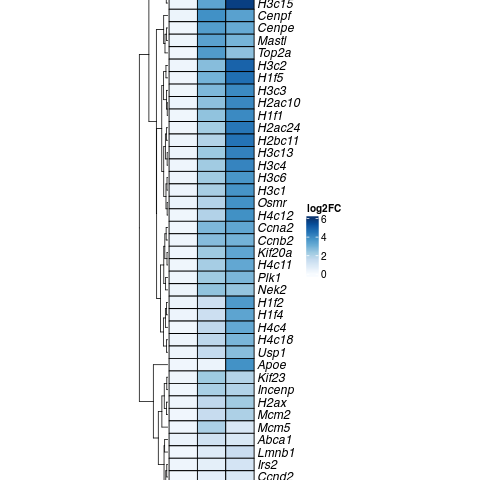

In [68]:
%%R
draw(h_both, merge_legend = TRUE)

## Summary line‐plot of mean log2FC per condition

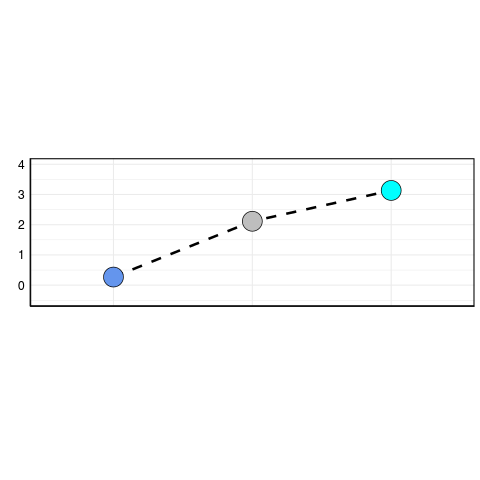

In [70]:
%%R

df_wide2 <- df_long %>% pivot_wider(names_from = type, values_from = log2fc)

value <- colMeans(df_wide2[ , c("S6-KO", "Step1", "Step2")] )
type  <- c("KO", "Step1", "Step2")
data  <- data.frame(value, type)

ggplot(data, aes(x = type, y = value)) +
  geom_line(aes(group = 1), size = 1.2, color = "black", linetype = "dashed") +
  geom_point(aes(fill = type), size = 9, shape = 21, color = "black") +
  xlab("") + ylab("") +
  theme_minimal() +
  theme(
    axis.text.y   = element_text(colour = "black", size = 12),
    axis.text.x   = element_blank(),
    axis.line     = element_line(colour = "black"),
    panel.border  = element_rect(colour = "black", fill = NA, size = 1),
    legend.position = "none",
    aspect.ratio  = 1/3
  ) +
  scale_fill_manual(values = c('cornflowerblue','grey','cyan')) +
  scale_y_continuous(limits = c(0,3.5), expand = expansion(0.2))

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: Removed 3 rows containing non-finite outside the scale range
(`stat_summary()`). 
  
R callback write-console: 2: Removed 3 rows containing non-finite outside the scale range
(`stat_summary()`). 
  
R callback write-console: 3: Removed 3 rows containing non-finite outside the scale range
(`stat_summary()`). 
  


In addition: Warning message:
The `fun.y` argument of `stat_summary()` is deprecated as of ggplot2 3.3.0.
ℹ Please use the `fun` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


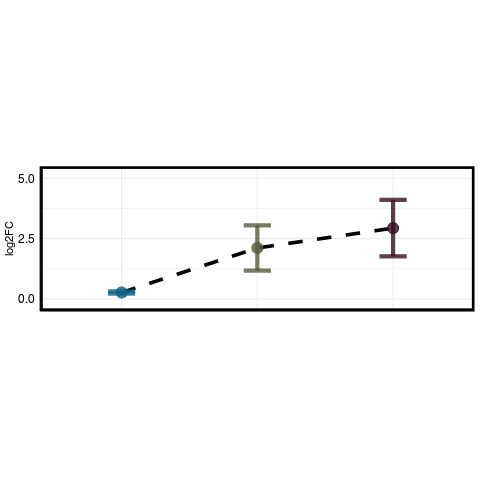

In [71]:
%%R

ggplot(df_long, aes(x=type, y=log2fc)) + 
    stat_summary(fun=mean, geom="line", aes(group=1), linetype = "dashed", size = 1.7) +
    stat_summary(aes(color = type), 
                 fun.data = mean_sdl, 
                 fun.args = list(mult=1), 
                 geom="errorbar", 
                 width=0.2, 
                 size = 2) + 
    stat_summary(aes(color = type), fun.y=mean, geom="point", size = 5) + 
    xlab(NULL) + ylab("log2FC")+
    theme_minimal() +
    theme(
        axis.text.y   = element_text(colour = "black", size = 12),
        axis.text.x   = element_blank(),
        axis.line     = element_line(colour = "black"),
        panel.border  = element_rect(colour = "black", fill = NA, size = 2.5),
        legend.position = "none",
        aspect.ratio  = 1/3
    ) +
    scale_y_continuous(limits = c(0, 5), breaks = c(0, 2.5, 5), expand = expansion(0.1))+
    scale_color_manual(values = c("#155F83CC", "#58593FCC", "#350E20CC")) 

## Down-regulated genes

In [72]:
%%R

shared_down_edo <- left_join(as.data.frame(edo_down_step1) %>% head(20) %>% dplyr::select(Description, p.adjust, Count), 
                        as.data.frame(edo_down_step2) %>% head(20) %>% dplyr::select(Description, p.adjust, Count), 
                        by = c("Description"))

colnames(shared_down_edo) <- c("Description", "Step1_padj", "Step1_Count", "Step2_padj", "Step2_Count")

shared_down_edo <- shared_down_edo %>%
  mutate(
    Step1_log10p = -log10(Step1_padj),
    Step2_log10p = -log10(Step2_padj)
  ) %>%
  arrange(desc(Step1_log10p + Step2_log10p))

Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'head': error in evaluating the argument 'x' in selecting a method for function 'as.data.frame': object 'edo_down_step1' not found


RInterpreterError: Failed to parse and evaluate line '\nshared_down_edo <- left_join(as.data.frame(edo_down_step1) %>% head(20) %>% dplyr::select(Description, p.adjust, Count), \n                        as.data.frame(edo_down_step2) %>% head(20) %>% dplyr::select(Description, p.adjust, Count), \n                        by = c("Description"))\n\ncolnames(shared_down_edo) <- c("Description", "Step1_padj", "Step1_Count", "Step2_padj", "Step2_Count")\n\nshared_down_edo <- shared_down_edo %>%\n  mutate(\n    Step1_log10p = -log10(Step1_padj),\n    Step2_log10p = -log10(Step2_padj)\n  ) %>%\n  arrange(desc(Step1_log10p + Step2_log10p))\n'.
R error message: "Error in h(simpleError(msg, call)) : \n  error in evaluating the argument 'x' in selecting a method for function 'head': error in evaluating the argument 'x' in selecting a method for function 'as.data.frame': object 'edo_down_step1' not found"

In [73]:
%%R

library(biomaRt)
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)
library(grid) 

mart <- useEnsembl("ENSEMBL_MART_ENSEMBL",
                   dataset = "mmusculus_gene_ensembl",
                   version = 108)

reactome_paths <- list(
  KO_Step1 = 'reactome_downregulated_common_DEGs_shSIRT6_Step1.csv',
  KO_Step2 = 'reactome_downregulated_common_DEGs_shSIRT6_Step2.csv'
)

react_df <- lapply(names(reactome_paths), function(tag) {
  read.csv(reactome_paths[[tag]], stringsAsFactors = FALSE) %>%
    mutate(tag = tag,
           gene = strsplit(as.character(geneID), "/")) %>%
    unnest(gene)
}) %>% bind_rows()

common_paths <- react_df %>%
  count(Description, tag) %>%
  group_by(Description) %>%
  filter(n() == length(unique(tag))) %>%
  pull(Description)

common_genes <- react_df %>%
  filter(Description %in% common_paths) %>%
  distinct(tag, gene) %>%
  count(gene) %>%
  filter(n == length(unique(react_df$tag))) %>%
  pull(gene)


# Annotation
ann <- getBM(filters    = "external_gene_name",
             attributes = c("external_gene_name", "ensembl_gene_id", "description"),
             values     = common_genes,
             mart       = mart)

deg_list <- list(
    `S6-KO` = sig_s6, 
    Step1   = sig_step1, 
    Step2   = sig_step2
)

df_long <- bind_rows(lapply(names(deg_list), function(lbl) {
    deg_list[[lbl]] %>%
    filter(gene %in% ann$ensembl_gene_id) %>%
    transmute(
      gene_id = symbol,
      log2fc  = log2FoldChange,
      type    = lbl
    )
})) %>%
  mutate(type = factor(type, levels = c("S6-KO", "Step1", "Step2")))

df_wide <- df_long %>%
  arrange(gene_id) %>%
  pivot_wider(names_from = type, values_from = log2fc) 

df_wide <- as.data.frame(df_wide)
rownames(df_wide) <- df_wide$gene_id
df_wide$gene_id <- NULL  

mat = as.matrix(df_wide)
mat_scaled = t(apply(mat, 1, scale))

base_mean = rowMeans(mat)
type = gsub("s\\d+_", "", colnames(mat))

col_fun = circlize::colorRamp2(seq(min(df_long$log2fc), 0, -min(df_long$log2fc)/8), rev(brewer.pal(9, "Blues")))

row_space <- unit(0.35, "cm")  
col_space <- unit(1., "cm")  

h_both <- Heatmap(
  mat, 
  name = "log2FC",
  show_column_names = F,
  col = col_fun,
  column_names_rot = 0,
  show_row_names = TRUE,
  column_order = c("S6-KO", "Step1", "Step2"),
  row_names_gp = gpar(fontsize = 12, fontface = "italic"), 
  rect_gp = gpar(col = "black", lwd = 1.2),
  row_labels = rownames(mat),  
  row_title_gp = gpar(fontsize = 8),
)

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: Removed 4 rows containing non-finite outside the scale range
(`stat_summary()`). 
  
R callback write-console: 2: Removed 4 rows containing non-finite outside the scale range
(`stat_summary()`). 
  
R callback write-console: 3: Removed 4 rows containing non-finite outside the scale range
(`stat_summary()`). 
  


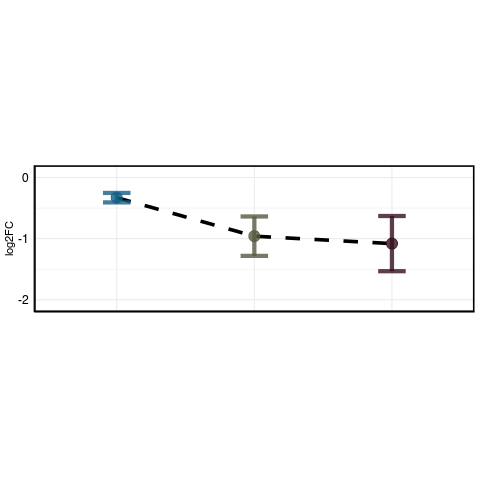

In [74]:
%%R

ggplot(df_long, aes(x=type, y=log2fc)) + 
    stat_summary(fun=mean, geom="line", aes(group=1), linetype = "dashed", size = 1.7) +
    stat_summary(aes(color = type), 
                 fun.data = mean_sdl, 
                 fun.args = list(mult=1), 
                 geom="errorbar", 
                 width=0.2, 
                 size = 2) + 
    stat_summary(aes(color = type), fun.y=mean, geom="point", size = 5) + 
    xlab(NULL) + ylab("log2FC")+
    theme_minimal() +
    theme(
        axis.text.y   = element_text(colour = "black", size = 12),
        axis.text.x   = element_blank(),
        axis.line     = element_line(colour = "black"),
        panel.border  = element_rect(colour = "black", fill = NA, size = 1.5),
        legend.position = "none",
        aspect.ratio  = 1/3
    ) +
    scale_y_continuous(limits = c(-2, 0), breaks = seq(-2, 0, 1), expand = expansion(0.1))+
    scale_color_manual(values = c("#155F83CC", "#58593FCC", "#350E20CC")) 

## TFs

In [ ]:
%%R
library(enrichR)
library(babelgene)

In [ ]:
%%R

library(enrichR)
library(tidyverse)
library(purrr)
library(babelgene)

ko_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_shSIRT6_shCtrl.csv', row.names = 1)
old_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Old_Control.csv', row.names = 1)
s1_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step1_Control.csv', row.names = 1)
s2_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step2_Control.csv', row.names = 1)

s1_all_filt <- s1_all %>% 
    dplyr::filter(baseMean > 0)
s2_all_filt <- s2_all %>% 
    dplyr::filter(baseMean > 0)
ko_all_filt <- ko_all %>% 
    dplyr::filter(baseMean > 0)
old_all_filt <- ko_all %>% 
    dplyr::filter(baseMean > 0)

background_list <- list(
    ko = ko_all_filt, 
    old = old_all_filt, 
    s1 = s1_all_filt, 
    s2 = s2_all_filt 
)

deg_files <- list(
    ko = sig_s6, 
    old = sig_old, 
    s1 = sig_step1, 
    s2 = sig_step2 
)

tf_library <- "ChEA_2022"

get_tfs <- function(gene_list, background = NULL) {
  if (length(gene_list) == 0) return(character(0))
  
  results <- enrichR::enrichr(genes = gene_list, databases = tf_library, background = background)
  res.df <- as.data.frame(results[[1]])
  
  res.df %>% 
    filter(grepl('Mouse', Term), Adjusted.P.value < 0.05) %>%
    mutate(Term = sub(" .*", "", Term)) %>%
    distinct(Term) %>%
    pull(Term)
}


process_deg_genes <- function(deg_files, background_list, output_dir = ".") {
  dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)
  tf_vectors <- list()
  
  for (name in names(deg_files)) {
    df <- deg_files[[name]]
    bg_genes <- pull(background_list[[name]], symbol)
    
    bg_human <- orthologs(bg_genes, "mouse", FALSE)$human_symbol %>% na.omit() %>% unique()
    write.table(bg_genes, file.path(output_dir, paste0("Background_genes_", name, ".txt")),
                quote = FALSE, row.names = FALSE, col.names = FALSE, sep = "\n")
    
    process_direction <- function(lfc_sign, direction) {
      genes <- df %>% filter(lfc_sign(log2FoldChange, 0)) %>% pull(symbol)
      human <- orthologs(genes, "mouse", FALSE)$human_symbol %>% na.omit() %>% unique()
      write.table(genes, file.path(output_dir, paste0(direction, "_regulated_genes_", name, ".txt")),
                  quote = FALSE, row.names = FALSE, col.names = FALSE, sep = "\n")
      get_tfs(human, bg_human)
    }
    
    tf_vectors[[name]]$down <- process_direction(`<`, "Down")
    tf_vectors[[name]]$up   <- process_direction(`>`, "Up")
  }
  
  tf_vectors
}

tf_vectors <- process_deg_genes(deg_files = deg_files, background_list = background_list)

In [ ]:
%%R

tf_vectors

## Upload and filter TFs associated with differential chromatin interactions from BART3D

In [ ]:
%%R

bart_files <- c(
  "WT_old_tr_Interaction_Increased_bart3d_results.txt",
  "WT_old_tr_Interaction_Decreased_bart3d_results.txt",
  "WT_KO_tr_Interaction_Increased_bart3d_results.txt",
  "WT_KO_tr_Interaction_Decreased_bart3d_results.txt",
  "control_step1_tr_Interaction_Increased_bart3d_results.txt", 
  "control_step1_tr_Interaction_Decreased_bart3d_results.txt",
  "control_step2_tr_Interaction_Increased_bart3d_results.txt",
  "control_step2_tr_Interaction_Decreased_bart3d_results.txt"
)

base_dir <- "/tank/projects/kashuk_sirt6_hic/tr/bart3d/cool_out2/"

TR_vectors <- list()

for (file in bart_files) {
  df <- read.table(file.path(base_dir, file), header = TRUE)
  df$p.adj <- p.adjust(df$pvalue, method = 'fdr')
  df_filt <- subset(df, p.adj < 0.05)
  vec_name <- tools::file_path_sans_ext(file)
  TR_vectors[[vec_name]] <- df_filt$TR
  saveRDS(df_filt$TR, file = paste0(vec_name, "_TRvector.rds"))
}

In [ ]:
%%R

cases <- list(
  old = "WT_old_tr_Interaction_Increased_bart3d_results_TRvector.rds",
  ko  = "WT_KO_tr_Interaction_Increased_bart3d_results_TRvector.rds",
  s1  = "control_step1_tr_Interaction_Increased_bart3d_results_TRvector.rds",
  s2  = "control_step2_tr_Interaction_Increased_bart3d_results_TRvector.rds"
)


up_lists <- lapply(names(cases), function(name) {
  hic_vec    <- readRDS(cases[[name]])
  rnaseq_vec <- tf_vectors[[name]]$up
  intersect(hic_vec, rnaseq_vec)
})

names(up_lists) <- names(cases)

In [ ]:
%%R

up_lists

In [ ]:
%%R

map <- c(
  ko = "KO_up",
  old = "Old_up", 
  s1 = "Step1_up",
  s2 = "Step2_up"
)

groups <- setNames(
  up_lists[names(map)],  
  map
)

group_colors <- c(
  KO_up    = 'cornflowerblue',
  Old_up = 'deeppink4',
  Step1_up = 'cyan',
  Step2_up = 'grey'
)

str(groups)

In [ ]:
%%R

library(circlize)

#png(filename = 'Circoplot_up_v3.png', width=3900, height=3700, res = 500)
grid::grid.newpage()

links <- do.call(rbind, lapply(names(groups), function(group_name) {
  data.frame(from = group_name, to = groups[[group_name]])
}))

pal <- brewer.pal(n = 11, name = "BrBG")

all_tfs <- unique(unlist(groups))
sector_order <- c(names(groups), all_tfs)
tf_link_count <- table(links$to)

tf_colors <- setNames(rep("#D3D4D8", length(all_tfs)), all_tfs)

names(tf_colors) <- names(tf_link_count)

tf_colors[tf_link_count > 1 & tf_link_count <= 2] <- pal[5]  
tf_colors[tf_link_count > 2 & tf_link_count <= 3] <- pal[4] 
tf_colors[tf_link_count > 3] <- pal[3]

sector_colors <- c(group_colors, tf_colors)


circos.clear()
circos.par(start.degree = 90, gap.degree = 1, cell.padding = c(0.3, 0, 0.02, 0))  # Adjust cell padding


circos.initialize(factors = sector_order, xlim = c(0, 1))

chordDiagram(
  links,
  transparency = 0.5,
  grid.col = sector_colors,  
  annotationTrack = "grid",
  preAllocateTracks = list(track.height = 0.1)
)

circos.trackPlotRegion(
  track.index = 1,
  panel.fun = function(x, y) {
    sector.name <- get.cell.meta.data("sector.index")
    xlim <- get.cell.meta.data("xlim")
    ylim <- get.cell.meta.data("ylim")
    

    label <- switch(sector.name,
                    "KO_up" = "SIRT6-KO up",
                    "KO_down" = "SIRT6-KO down",
                    "Old_up" = "Old up",
                    "Old_down" = "Old down",
                    "Step1_up" = "Step1 up",
                    "Step1_down" = "Step1 down",
                    "Step2_up" = "Step2 up",
                    "Step2_down" = "Step2 down",
                    sector.name)  
    
    circos.text(
      mean(xlim), ylim[1], label,
      facing = "clockwise", niceFacing = TRUE,
      adj = c(0, 0.5), cex = 1.13,  
    )
  },
  bg.border = NA
)

#dev.off()

In [ ]:
%%R

cases <- list(
  old = "WT_old_tr_Interaction_Decreased_bart3d_results_TRvector.rds",
  ko  = "WT_KO_tr_Interaction_Decreased_bart3d_results_TRvector.rds",
  s1  = "control_step1_tr_Interaction_Decreased_bart3d_results_TRvector.rds",
  s2  = "control_step2_tr_Interaction_Decreased_bart3d_results_TRvector.rds"
)


down_lists <- lapply(names(cases), function(name) {
  hic_vec    <- readRDS(cases[[name]])
  rnaseq_vec <- tf_vectors[[name]]$down
  intersect(hic_vec, rnaseq_vec)
})

names(down_lists) <- names(cases)

down_lists

In [ ]:
%%R

map <- c(
  ko = "KO_down",
  old = "Old_down",
  s1 = "Step1_down",
  s2 = "Step2_down"
)

groups <- setNames(
  down_lists[names(map)],  
  map
)

group_colors <- c(
  KO_down = 'cornflowerblue',
  Old_down = 'deeppink4',
  Step1_down = 'cyan', 
  Step2_down = 'grey'
)

str(groups)

In [94]:
%%R

library(circlize)

png(filename = 'Circoplot_down_v3.png', width=3900, height=3700, res = 500)
grid::grid.newpage()

links <- do.call(rbind, lapply(names(groups), function(group_name) {
  data.frame(from = group_name, to = groups[[group_name]])
}))


all_tfs <- unique(unlist(groups))
sector_order <- c(names(groups), all_tfs)

tf_link_count <- table(links$to)

tf_colors <- setNames(rep("#D3D4D8", length(all_tfs)), all_tfs)

names(tf_colors) <- names(tf_link_count)

tf_colors[tf_link_count > 1 & tf_link_count <= 2] <- pal[5]  
tf_colors[tf_link_count > 2 & tf_link_count <= 3] <- pal[4] 
tf_colors[tf_link_count > 3] <- pal[3]

sector_colors <- c(group_colors, tf_colors)

circos.clear()
circos.par(start.degree = 90, gap.degree = 1, cell.padding = c(0.3, 0, 0.02, 0))  # Adjust cell padding

circos.initialize(factors = sector_order, xlim = c(0, 1))

chordDiagram(
  links,
  transparency = 0.5,
  grid.col = sector_colors,  
  annotationTrack = "grid",
  preAllocateTracks = list(track.height = 0.1)
)

circos.trackPlotRegion(
  track.index = 1,
  panel.fun = function(x, y) {
    sector.name <- get.cell.meta.data("sector.index")
    xlim <- get.cell.meta.data("xlim")
    ylim <- get.cell.meta.data("ylim")
    

    label <- switch(sector.name,
                    "KO_up" = "SIRT6-KO up",
                    "KO_down" = "SIRT6-KO down",
                    "Old_down" = "Old down",
                    "Step1_up" = "Step1 up",
                    "Step1_down" = "Step1 down",
                    "Step2_up" = "Step2 up",
                    "Step2_down" = "Step2 down",
                    sector.name)  
    
    circos.text(
      mean(xlim), ylim[1], label,
      facing = "clockwise", niceFacing = TRUE,
      adj = c(0, 0.5), cex = 1.13,
      col = ifelse(sector.name == "REST", "darkorange3", "black")  
    )
  },
  bg.border = NA
)

dev.off()

png 
  2 


In [95]:
%%R
library(ggpubr)
library(ComplexHeatmap)

lgd = Legend(labels = 1:4, title = "Number\nof links", legend_gp = gpar(fill = c("#D3D4D8", pal[c(5:3)])))

png(filename = 'Circoplot_down_legend.png', width=600, height=900, res = 700)
grid::grid.newpage()

draw(lgd)
dev.off()

png 
  2 


In [367]:
%%R

sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/liblapack.so.3;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Moscow
tzcode source: system (glibc)

attached base packages:
 [1] grid      stats4    tools     stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] cowplot_1.1.3                         
 [2] circlize_0.4.16                       
 [3] DOSE_4.0.0                            
 [4] ggtree_3.1